## Stratified Sampling for Query Generation (W1 / W2 / W3)

Selects the source material for query generation: 50 chunks each for W1 (short factual), W2 (multi-hop), and W3 (semantic similarity), per category, per corpus type (abstracts and PDF chunks), across all 10 categories (yours and Sadman's).

**Why not "start, middle, end of the file"**: this was the original framing, but positional sampling within a JSONL file samples whatever ordering the file happens to be in, which for this corpus is roughly arXiv ID order, i.e. roughly *submission date*. Sampling by file position would therefore sample by time period, not by topic, and could easily skew the query set toward, say, 2021-2022 papers or 2024-2025 papers depending on where "start/middle/end" thirds happen to fall, without that being visible or intended. This has nothing to do with representing the topical population, which was the actual goal.

**Why stratified-by-cluster instead**: the BERTopic clustering already run for W3 ground truth gives each chunk a `bertopic_topic` label representing its actual sub-theme within the category. Sampling proportionally to cluster size (a cluster with 20% of a category's mass contributes ~20% of that category's sample) is a direct, defensible operationalization of "represents the entire population": the sample's topical composition mirrors the corpus's topical composition, rather than mirroring an arbitrary file ordering. This also reuses existing pipeline work rather than introducing a new, uncorrelated sampling mechanism.

**Sample structure per category, per corpus type**:
- W1 pool: 50 chunks, stratified by cluster, drawn independently
- W2 pool: 50 chunk **pairs** (100 chunks total, but organized as 50 pairs), each pair drawn from either the same cluster or the nearest neighboring cluster (by centroid distance), stratified so pair-source-clusters are proportional to cluster size
- W3 pool: 50 chunks, stratified by cluster, drawn independently
- All three pools are drawn **independently** of each other (a chunk can appear in more than one pool by chance, this is accepted, not deduplicated across workload types, since each workload type needs its own representative sample of the population, not a partition of one shared sample)

**Outliers (`bertopic_topic == -1`) are excluded from stratified sampling**: outlier points don't belong to any coherent sub-theme by BERTopic's own definition, so including them in a population-representative sample would be sampling noise, not population. They're reported separately (excluded count, percentage) for transparency, not silently dropped without a trace.

### Install dependencies (Colab only, skip if already installed locally)

In [ ]:
# Uncomment if running in Colab or a fresh environment
# !pip install huggingface_hub pandas numpy matplotlib -q

### Configuration

In [ ]:
import os

# --- Hugging Face repo (shared corpus) ---
REPO_ID = "Sakhiur/empirical-rag-paradigm-benchmark"
REPO_TYPE = "dataset"

# --- Which embeddings/clusters to sample against ---
EMBEDDING_MODEL = "text-embedding-3-small"

# --- All 10 categories ---
ALL_CATEGORIES = [
    "cs.AI", "cs.LG", "cs.IR", "cs.DB", "cs.SE",       
    "cs.CV", "cs.CL", "cs.NE", "cs.DC", "cs.CR",      
]

# --- Sample sizes ---
N_PER_WORKLOAD = 50   # W1, W2 (pairs), W3 each get 50 per category per corpus type

# --- Reproducibility ---
RANDOM_STATE = 42

# --- Visualization settings, IEEE format ---
IEEE_COLUMN_WIDTH_INCHES = 3.5
IEEE_FULL_WIDTH_INCHES = 7.16
IEEE_FIGURE_DPI = 300

# --- Local paths ---
PROJECT_ROOT = ".."
SAMPLES_DIR = os.path.join(PROJECT_ROOT, "data", "query_samples", EMBEDDING_MODEL)
FIGURES_DIR = os.path.join(PROJECT_ROOT, "results", "figures", "sampling")
for corpus_type in ["abstracts", "pdf_chunks"]:
    for workload in ["w1", "w2", "w3"]:
        os.makedirs(os.path.join(SAMPLES_DIR, corpus_type, workload), exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

FORCE_RESAMPLE = False

### Authenticate with Hugging Face

In [2]:
from huggingface_hub import whoami, login

try:
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")
except Exception:
    print("Not authenticated yet, prompting for token...")
    login()
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")

c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authenticated as: Sakhiur


### Loader functions

Joins three artifacts per (category, corpus_type): source records (for text), embeddings (for computing cluster centroids, needed for W2 adjacency), and BERTopic cluster assignments (for stratification). All three were produced by earlier notebooks in this pipeline and already live on the Hub.

In [3]:
import json
import numpy as np
from huggingface_hub import hf_hub_download


def load_source_records(category: str, corpus_type: str) -> dict[str, dict]:
    if corpus_type == "abstracts":
        repo_path = f"abstracts/by_category/{category}.jsonl"
    else:
        repo_path = f"pdf_chunks/{category}.jsonl"
    try:
        local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    except Exception:
        return {}

    result = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            chunk_id = record["id"] if corpus_type == "abstracts" else f"{record['paper_id']}_p{record['page_num']}"
            result[chunk_id] = record
    return result


def load_embeddings(category: str, corpus_type: str) -> dict[str, list[float]]:
    repo_path = f"embeddings/{EMBEDDING_MODEL}/{corpus_type}/{category}.jsonl"
    try:
        local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    except Exception:
        return {}

    result = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            result[record["chunk_id"]] = record["embedding"]
    return result


def load_bertopic_clusters(category: str, corpus_type: str) -> dict[str, int]:
    repo_path = f"bertopic/{EMBEDDING_MODEL}/{corpus_type}/{category}.jsonl"
    try:
        local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    except Exception:
        return {}

    result = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            result[record["chunk_id"]] = record["bertopic_topic"]
    return result


def build_joined_table(category: str, corpus_type: str) -> dict:
    """
    Joins source records, embeddings, and cluster labels on chunk_id.
    Returns None if any of the three artifacts is missing (category not yet
    uploaded/processed, e.g. collaborator's categories before he runs the pipeline).
    Only chunk_ids present in all three are kept, since sampling needs all three
    pieces of information for every candidate chunk.
    """
    source = load_source_records(category, corpus_type)
    embeddings = load_embeddings(category, corpus_type)
    clusters = load_bertopic_clusters(category, corpus_type)

    if not source or not embeddings or not clusters:
        return None

    common_ids = set(source) & set(embeddings) & set(clusters)
    if not common_ids:
        return None

    return {
        "chunk_ids": sorted(common_ids),
        "source": {cid: source[cid] for cid in common_ids},
        "embeddings": {cid: np.array(embeddings[cid], dtype=np.float32) for cid in common_ids},
        "clusters": {cid: clusters[cid] for cid in common_ids},
    }

### Stratified sampling function (W1 / W3, single-chunk pools)

**Why proportional allocation, not equal allocation per cluster**: an alternative would be to take an equal number of samples from every cluster regardless of size (e.g. 5 from each of 10 clusters). This was rejected because it would systematically over-represent small, niche clusters and under-represent large, common sub-themes, which contradicts "represent the entire population." Proportional allocation (cluster with 20% of the category's mass gets ~20% of the 50 samples) is the standard definition of stratified sampling for population representativeness, and is what's implemented here via `np.random.choice` with per-cluster sample counts computed from cluster size ratios.

**Rounding**: proportional allocation across integer sample counts rarely divides evenly (50 samples across, say, 7 clusters of uneven size). Largest-remainder rounding is used: compute each cluster's exact proportional share as a float, take the floor, then distribute the leftover samples (from rounding down) to the clusters with the largest fractional remainders. This guarantees the total is always exactly 50, rather than a rounding-drifted number like 48 or 52, while staying as close as possible to true proportionality.

**Clusters smaller than their allocated share**: if a cluster's true size is smaller than what proportional allocation would assign (rare, but possible for very small clusters combined with rounding), the function takes the whole cluster and redistributes the shortfall to the next-largest clusters, rather than sampling with replacement (which would let a chunk appear twice in the same pool, undermining the population-representative goal).

In [4]:
def compute_proportional_allocation(cluster_sizes: dict[int, int], n_total: int) -> dict[int, int]:
    """
    Given {cluster_id: size} and a total sample budget, returns {cluster_id: n_to_sample}
    using largest-remainder rounding so allocations sum exactly to n_total (or less,
    if the population itself has fewer than n_total points).
    """
    population_size = sum(cluster_sizes.values())
    if population_size <= n_total:
        return dict(cluster_sizes)  # take everything, population is smaller than the target sample

    exact_shares = {cid: n_total * size / population_size for cid, size in cluster_sizes.items()}
    floor_shares = {cid: int(np.floor(share)) for cid, share in exact_shares.items()}

    # cap floor at cluster size (should not happen given the floor, but guards degenerate cases)
    floor_shares = {cid: min(floor_shares[cid], cluster_sizes[cid]) for cid in floor_shares}

    allocated = sum(floor_shares.values())
    remainder = n_total - allocated

    remainders = sorted(
        cluster_sizes.keys(),
        key=lambda cid: (exact_shares[cid] - floor_shares[cid]),
        reverse=True,
    )

    i = 0
    while remainder > 0 and i < len(remainders) * 3:  # bounded loop, avoids infinite loop on edge cases
        cid = remainders[i % len(remainders)]
        if floor_shares[cid] < cluster_sizes[cid]:
            floor_shares[cid] += 1
            remainder -= 1
        i += 1

    return floor_shares


def stratified_sample(joined: dict, n_total: int, rng: np.random.Generator) -> list[str]:
    """
    Draws a stratified sample of chunk_ids, proportional to BERTopic cluster size.
    Outlier points (cluster == -1) are excluded from the sampling population.
    """
    by_cluster: dict[int, list[str]] = {}
    for cid in joined["chunk_ids"]:
        cluster = joined["clusters"][cid]
        if cluster == -1:
            continue
        by_cluster.setdefault(cluster, []).append(cid)

    if not by_cluster:
        return []

    cluster_sizes = {cid: len(members) for cid, members in by_cluster.items()}
    allocation = compute_proportional_allocation(cluster_sizes, n_total)

    sampled = []
    for cluster_id, n_from_cluster in allocation.items():
        members = by_cluster[cluster_id]
        chosen = rng.choice(members, size=min(n_from_cluster, len(members)), replace=False)
        sampled.extend(chosen.tolist())

    return sampled

### W2 pairing function (multi-hop, cluster-stratified pairs)

**Defining "adjacent cluster" precisely**: BERTopic doesn't provide a built-in notion of cluster adjacency, so this needs an explicit, computable definition rather than a vague one. Here, a cluster centroid is computed as the mean embedding of its member chunks, then "adjacent" means the nearest other centroid by cosine distance. This gives every cluster exactly one well-defined adjacent cluster, computed the same way every time (reproducible), and ties directly to the embedding geometry already used everywhere else in this pipeline.

**Why pairs come from the same-or-adjacent cluster, not any two random clusters**: a pair from two unrelated clusters (e.g. a cs.DB paper on query optimization paired with a cs.DB paper on distributed transactions) has no natural comparison to ask about, forcing Gemini to either fabricate a connection or produce a generic, low-quality multi-hop question. Same-cluster pairs support "how do paper A and paper B's approaches to the same sub-problem differ," and adjacent-cluster pairs support "how does paper A's approach in sub-theme X relate to or differ from paper B's approach in the neighboring sub-theme Y," both of which are answerable, genuine comparison questions, unlike a random cross-cluster pair.

**Stratification for W2**: 50 pairs are allocated across clusters proportionally to cluster size, same logic as W1/W3, so the topical distribution of W2's pair-sources also mirrors the category's population, not just W1 and W3's single-chunk pools.

**Pair composition**: for each allocated cluster, roughly half its pairs are same-cluster (two different chunks from that cluster) and half are cross-cluster (one chunk from that cluster, one from its nearest adjacent cluster), giving a mix of "compare two takes on the same sub-topic" and "compare two related-but-distinct sub-topics" questions, rather than only one pairing style.

In [5]:
def compute_cluster_centroids(joined: dict) -> dict[int, np.ndarray]:
    """Mean embedding per cluster, excluding outliers (-1)."""
    by_cluster: dict[int, list[np.ndarray]] = {}
    for cid in joined["chunk_ids"]:
        cluster = joined["clusters"][cid]
        if cluster == -1:
            continue
        by_cluster.setdefault(cluster, []).append(joined["embeddings"][cid])

    centroids = {}
    for cluster_id, vectors in by_cluster.items():
        stacked = np.stack(vectors)
        centroid = stacked.mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-8)  # normalize for cosine comparison
        centroids[cluster_id] = centroid
    return centroids


def find_nearest_adjacent_cluster(cluster_id: int, centroids: dict[int, np.ndarray]) -> int | None:
    """Returns the cluster_id of the nearest OTHER cluster centroid by cosine distance, or None if only one cluster exists."""
    other_ids = [cid for cid in centroids if cid != cluster_id]
    if not other_ids:
        return None

    this_centroid = centroids[cluster_id]
    similarities = {cid: float(np.dot(this_centroid, centroids[cid])) for cid in other_ids}
    return max(similarities, key=similarities.get)  # highest cosine similarity = nearest


def stratified_pair_sample(joined: dict, n_pairs: int, rng: np.random.Generator) -> list[tuple[str, str, str]]:
    """
    Draws n_pairs stratified chunk-id pairs for W2.
    Returns a list of (chunk_id_a, chunk_id_b, pair_type) tuples, where pair_type
    is 'same_cluster' or 'adjacent_cluster', kept for transparency in the output CSV.
    """
    by_cluster: dict[int, list[str]] = {}
    for cid in joined["chunk_ids"]:
        cluster = joined["clusters"][cid]
        if cluster == -1:
            continue
        by_cluster.setdefault(cluster, []).append(cid)

    # only clusters with 2+ members can supply a same-cluster pair or serve as a pair anchor
    eligible_clusters = {cid: members for cid, members in by_cluster.items() if len(members) >= 2}
    if not eligible_clusters:
        return []

    centroids = compute_cluster_centroids(joined)
    cluster_sizes = {cid: len(members) for cid, members in eligible_clusters.items()}
    allocation = compute_proportional_allocation(cluster_sizes, n_pairs)

    pairs = []
    for cluster_id, n_from_cluster in allocation.items():
        members = eligible_clusters[cluster_id]
        n_same = n_from_cluster // 2
        n_adjacent = n_from_cluster - n_same

        for _ in range(n_same):
            if len(members) < 2:
                break
            a, b = rng.choice(members, size=2, replace=False)
            pairs.append((a, b, "same_cluster"))

        adjacent_id = find_nearest_adjacent_cluster(cluster_id, centroids)
        if adjacent_id is not None and adjacent_id in by_cluster:
            adjacent_members = by_cluster[adjacent_id]
            for _ in range(n_adjacent):
                a = rng.choice(members)
                b = rng.choice(adjacent_members)
                pairs.append((str(a), str(b), "adjacent_cluster"))

    return pairs[:n_pairs]  # trim in case allocation produced a few extra from rounding

### Run sampling across all categories and both corpus types

Categories missing any of the three required artifacts (source, embeddings, clusters) are skipped and reported, not treated as an error, expected for categories not yet fully processed through the pipeline. A single `rng` (seeded once) is threaded through every draw, not re-seeded per category, so the full sequence of random draws across the whole run is reproducible end to end, not just reproducible category by category in isolation.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)

all_samples = {}   # {(corpus_type, category, workload): sample data}
skipped = []

for corpus_type in ["abstracts", "pdf_chunks"]:
    for category in ALL_CATEGORIES:
        print(f"\n=== {corpus_type} / {category} ===")

        joined = build_joined_table(category, corpus_type)
        if joined is None:
            print(f"  [SKIP] missing source/embeddings/clusters, not yet processed")
            skipped.append((corpus_type, category))
            continue

        total_chunks = len(joined["chunk_ids"])
        n_outliers = sum(1 for cid in joined["chunk_ids"] if joined["clusters"][cid] == -1)
        print(f"  {total_chunks} chunks total, {n_outliers} outliers ({100*n_outliers/total_chunks:.1f}%) excluded from sampling")

        w1_sample = stratified_sample(joined, N_PER_WORKLOAD, rng)
        w3_sample = stratified_sample(joined, N_PER_WORKLOAD, rng)
        w2_pairs = stratified_pair_sample(joined, N_PER_WORKLOAD, rng)

        print(f"  W1: {len(w1_sample)}/{N_PER_WORKLOAD} sampled")
        print(f"  W2: {len(w2_pairs)}/{N_PER_WORKLOAD} pairs sampled")
        print(f"  W3: {len(w3_sample)}/{N_PER_WORKLOAD} sampled")

        all_samples[(corpus_type, category, "w1")] = {"chunk_ids": w1_sample, "joined": joined}
        all_samples[(corpus_type, category, "w3")] = {"chunk_ids": w3_sample, "joined": joined}
        all_samples[(corpus_type, category, "w2")] = {"pairs": w2_pairs, "joined": joined}

print(f"\n\nSkipped (missing artifacts): {skipped if skipped else 'none'}")


=== abstracts / cs.AI ===


c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sakhiur\.cache\huggingface\hub\datasets--Sakhiur--empirical-rag-paradigm-benchmark. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  7369 chunks total, 3081 outliers (41.8%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.LG ===
  10746 chunks total, 3550 outliers (33.0%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.IR ===
  3076 chunks total, 1024 outliers (33.3%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.DB ===
  1532 chunks total, 510 outliers (33.3%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.SE ===
  2281 chunks total, 800 outliers (35.1%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.CV ===
  14163 chunks total, 3835 outliers (27.1%) excluded from sampling
  W1: 50/50 sampled
  W2: 50/50 pairs sampled
  W3: 50/50 sampled

=== abstracts / cs.CL ===
  12418 chunks total, 3916 outliers (31.5%) ex

### Export CSVs

**W1/W3 CSV columns**: `chunk_id`, `category`, `bertopic_cluster`, `text` (or `title` for abstracts), so the CSV is directly usable as input to the next stage (Gemini query generation) without needing to re-join against the Hub.

**W2 CSV columns**: `pair_id`, `category`, `chunk_id_a`, `chunk_id_b`, `pair_type` (same_cluster / adjacent_cluster), `cluster_a`, `cluster_b`, plus both chunks' text, so a downstream query-generation script has everything needed to prompt for a comparison question without any additional lookups.

In [7]:
import pandas as pd


def get_display_text(record: dict, corpus_type: str) -> str:
    return record["text"]


def get_display_title(record: dict, corpus_type: str) -> str:
    if corpus_type == "abstracts":
        return record.get("title", "")
    return ""  # PDF chunks have no title field


csv_paths = {}

for (corpus_type, category, workload), data in all_samples.items():
    out_path = os.path.join(SAMPLES_DIR, corpus_type, workload, f"{category}.csv")

    if os.path.exists(out_path) and not FORCE_RESAMPLE:
        print(f"[SKIP] {corpus_type}/{workload}/{category}: already exists at {out_path}")
        csv_paths[(corpus_type, category, workload)] = out_path
        continue

    joined = data["joined"]

    if workload in ("w1", "w3"):
        rows = []
        for cid in data["chunk_ids"]:
            record = joined["source"][cid]
            rows.append({
                "chunk_id": cid,
                "category": category,
                "bertopic_cluster": joined["clusters"][cid],
                "title": get_display_title(record, corpus_type),
                "text": get_display_text(record, corpus_type),
            })
        df = pd.DataFrame(rows)

    else:  # w2
        rows = []
        for i, (cid_a, cid_b, pair_type) in enumerate(data["pairs"]):
            record_a = joined["source"][cid_a]
            record_b = joined["source"][cid_b]
            rows.append({
                "pair_id": f"{category}_w2_{i:03d}",
                "category": category,
                "pair_type": pair_type,
                "chunk_id_a": cid_a,
                "cluster_a": joined["clusters"][cid_a],
                "title_a": get_display_title(record_a, corpus_type),
                "text_a": get_display_text(record_a, corpus_type),
                "chunk_id_b": cid_b,
                "cluster_b": joined["clusters"][cid_b],
                "title_b": get_display_title(record_b, corpus_type),
                "text_b": get_display_text(record_b, corpus_type),
            })
        df = pd.DataFrame(rows)

    df.to_csv(out_path, index=False)
    csv_paths[(corpus_type, category, workload)] = out_path
    print(f"Saved {out_path} ({len(df)} rows)")

Saved ..\data\query_samples\text-embedding-3-small\abstracts\w1\cs.AI.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w3\cs.AI.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w2\cs.AI.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w1\cs.LG.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w3\cs.LG.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w2\cs.LG.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w1\cs.IR.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w3\cs.IR.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w2\cs.IR.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w1\cs.DB.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w3\cs.DB.csv (50 rows)
Saved ..\data\query_samples\text-embedding-3-small\abstracts\w2\cs.DB.csv (5

### Figure: sample representativeness (population vs sample cluster proportions)

**Why this specific figure, not just a sample-size bar chart**: the entire justification for stratified-by-cluster sampling was "the sample's topical composition should mirror the population's topical composition." A figure showing sample counts alone doesn't demonstrate that claim, it just shows how many were sampled. This figure instead plots population proportion vs sample proportion side by side per cluster, so a reader (or your supervisor) can visually verify the stratification actually worked, rather than taking the methodology's correctness on faith. A well-executed stratified sample should show the two bars closely matching for every cluster; any visible mismatch would itself be a useful diagnostic (e.g. a cluster too small to hit its exact proportional share after integer rounding).

**One figure per category, per corpus type, per workload type**: kept separate rather than combined into one mega-figure, since W1 and W3 are drawn independently and could show slightly different sampled compositions by chance even though they use the same allocation logic, worth being able to inspect each draw individually rather than averaging away real differences between them.

In [8]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})


def plot_representativeness(joined: dict, sampled_chunk_ids: list[str], corpus_type: str, category: str, workload: str, out_path: str) -> None:
    population_by_cluster: dict[int, int] = {}
    for cid in joined["chunk_ids"]:
        cluster = joined["clusters"][cid]
        if cluster == -1:
            continue
        population_by_cluster[cluster] = population_by_cluster.get(cluster, 0) + 1

    sample_by_cluster: dict[int, int] = {}
    for cid in sampled_chunk_ids:
        cluster = joined["clusters"][cid]
        sample_by_cluster[cluster] = sample_by_cluster.get(cluster, 0) + 1

    clusters = sorted(population_by_cluster.keys())
    pop_total = sum(population_by_cluster.values())
    sample_total = sum(sample_by_cluster.values()) or 1

    pop_pct = [100 * population_by_cluster[c] / pop_total for c in clusters]
    sample_pct = [100 * sample_by_cluster.get(c, 0) / sample_total for c in clusters]

    x = np.arange(len(clusters))
    width = 0.38

    fig, ax = plt.subplots(figsize=(IEEE_COLUMN_WIDTH_INCHES, 2.2))
    ax.bar(x - width/2, pop_pct, width, label="Population %", color="#4C72B0")
    ax.bar(x + width/2, sample_pct, width, label="Sample %", color="#DD8452")

    ax.set_xlabel("BERTopic cluster")
    ax.set_ylabel("% of chunks")
    ax.set_title(f"{category} ({corpus_type}, {workload.upper()}): population vs sample")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T{c}" for c in clusters])
    ax.legend()
    ax.grid(alpha=0.25, axis="y")

    fig.tight_layout()
    fig.savefig(out_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)

### Generate per-category representativeness figures

Runs for W1 and W3 (single-chunk pools, direct cluster membership). W2 is handled separately in the next section since its unit is pairs, not individual chunks, and needs a different representativeness framing (pair-source-cluster coverage, not per-chunk cluster coverage).

In [9]:
for (corpus_type, category, workload), data in all_samples.items():
    if workload not in ("w1", "w3"):
        continue

    fig_path = os.path.join(FIGURES_DIR, f"{corpus_type}_{category}_{workload}_representativeness.png")
    if os.path.exists(fig_path) and not FORCE_RESAMPLE:
        print(f"[SKIP] {fig_path} already exists")
        continue

    plot_representativeness(data["joined"], data["chunk_ids"], corpus_type, category, workload, fig_path)
    print(f"Saved {fig_path}")

Saved ..\results\figures\sampling\abstracts_cs.AI_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.AI_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.LG_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.LG_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.IR_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.IR_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.DB_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.DB_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.SE_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.SE_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.CV_w1_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.CV_w3_representativeness.png
Saved ..\results\figures\sampling\abstracts_cs.CL_w1_representativeness.png
Saved ..\res

### Cross-category summary figure: sampling coverage overview

**Why this figure**: individual per-category, per-workload representativeness plots (above) are the rigorous, granular evidence, but a reader (or a supervisor skimming the paper) benefits from one consolidated view showing sample coverage across all 10 categories and all three workload types at once. This figure reports, per category and workload type, the **total variation distance** between the population's cluster-proportion distribution and the sample's cluster-proportion distribution, a single number in [0, 1] where 0 means the sample's topical composition perfectly matches the population's, and higher values indicate more divergence. This is the standard way to compress a full distributional comparison (like the bar-pair plots above) into one comparable number across many categories, rather than requiring 30 separate bar charts to be read side by side.

**Total variation distance formula**: TVD = 0.5 * sum(|population_proportion_c - sample_proportion_c|) over all clusters c. Bounded in [0, 1]. This is computed directly from the same population/sample cluster counts used in the per-category bar charts, so the summary figure and the detailed figures are guaranteed to tell a consistent story, not two independently-computed metrics that could disagree.

In [10]:
def total_variation_distance(joined: dict, sampled_chunk_ids: list[str]) -> float:
    population_by_cluster: dict[int, int] = {}
    for cid in joined["chunk_ids"]:
        cluster = joined["clusters"][cid]
        if cluster == -1:
            continue
        population_by_cluster[cluster] = population_by_cluster.get(cluster, 0) + 1

    sample_by_cluster: dict[int, int] = {}
    for cid in sampled_chunk_ids:
        cluster = joined["clusters"][cid]
        sample_by_cluster[cluster] = sample_by_cluster.get(cluster, 0) + 1

    pop_total = sum(population_by_cluster.values())
    sample_total = sum(sample_by_cluster.values()) or 1

    all_clusters = set(population_by_cluster) | set(sample_by_cluster)
    tvd = 0.5 * sum(
        abs(population_by_cluster.get(c, 0) / pop_total - sample_by_cluster.get(c, 0) / sample_total)
        for c in all_clusters
    )
    return tvd


tvd_rows = []
for (corpus_type, category, workload), data in all_samples.items():
    if workload not in ("w1", "w3"):
        continue
    tvd = total_variation_distance(data["joined"], data["chunk_ids"])
    tvd_rows.append({"corpus_type": corpus_type, "category": category, "workload": workload, "tvd": tvd})

tvd_df = pd.DataFrame(tvd_rows)

tvd_csv_path = os.path.join(SAMPLES_DIR, "sampling_representativeness_tvd.csv")
tvd_df.to_csv(tvd_csv_path, index=False)
print(f"Saved {tvd_csv_path}")
tvd_df

Saved ..\data\query_samples\text-embedding-3-small\sampling_representativeness_tvd.csv


,corpus_type,category,workload,tvd
0,abstracts,cs.AI,w1,0.373946
1,abstracts,cs.AI,w3,0.373946
2,abstracts,cs.LG,w1,0.362084
3,abstracts,cs.LG,w3,0.362084
4,abstracts,cs.IR,w1,0.171813
5,abstracts,cs.IR,w3,0.171813
6,abstracts,cs.DB,w1,0.083483
7,abstracts,cs.DB,w3,0.083483
8,abstracts,cs.SE,w1,0.174072
9,abstracts,cs.SE,w3,0.174072


### Grand summary figure: TVD across all categories and workload types

One double-column-width figure for the paper: grouped bars, one group per category, W1 and W3 TVD side by side within each group, all 10 categories in one frame. This is the figure that directly answers "does the stratified sampling actually represent the population," across the entire corpus, in one glance, backed by the per-category detail figures and the raw CSV for anyone who wants to verify a specific category more closely.

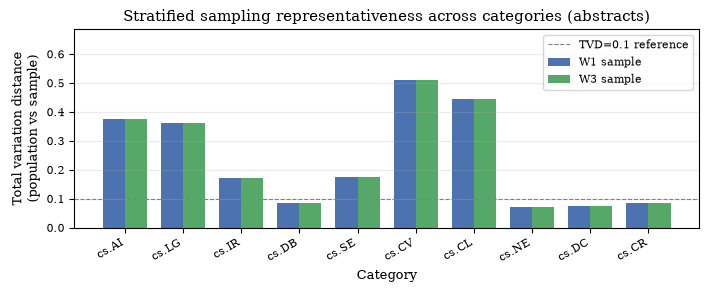

Saved ..\results\figures\sampling\grand_summary_tvd_abstracts.png


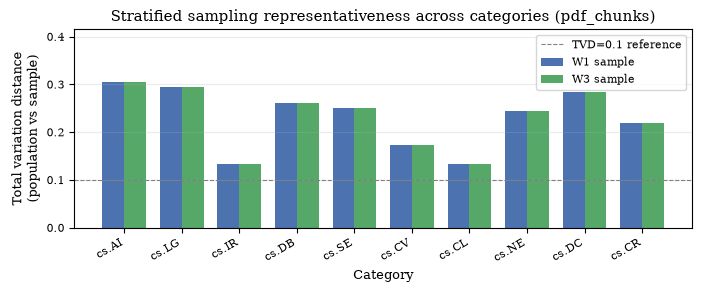

Saved ..\results\figures\sampling\grand_summary_tvd_pdf_chunks.png


In [11]:
plt.rcParams.update({
    "font.size": 9,
    "font.family": "serif",
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

for corpus_type in ["abstracts", "pdf_chunks"]:
    subset = tvd_df[tvd_df["corpus_type"] == corpus_type]
    if subset.empty:
        continue

    categories_present = [c for c in ALL_CATEGORIES if c in subset["category"].values]
    w1_vals = [subset[(subset["category"] == c) & (subset["workload"] == "w1")]["tvd"].values[0]
               if not subset[(subset["category"] == c) & (subset["workload"] == "w1")].empty else 0
               for c in categories_present]
    w3_vals = [subset[(subset["category"] == c) & (subset["workload"] == "w3")]["tvd"].values[0]
               if not subset[(subset["category"] == c) & (subset["workload"] == "w3")].empty else 0
               for c in categories_present]

    x = np.arange(len(categories_present))
    width = 0.38

    fig, ax = plt.subplots(figsize=(IEEE_FULL_WIDTH_INCHES, 3.0))
    ax.bar(x - width/2, w1_vals, width, label="W1 sample", color="#4C72B0")
    ax.bar(x + width/2, w3_vals, width, label="W3 sample", color="#55A868")

    ax.axhline(0.1, color="gray", linestyle="--", linewidth=0.8, label="TVD=0.1 reference")

    ax.set_xlabel("Category")
    ax.set_ylabel("Total variation distance\n(population vs sample)")
    ax.set_title(f"Stratified sampling representativeness across categories ({corpus_type})")
    ax.set_xticks(x)
    ax.set_xticklabels(categories_present, rotation=30, ha="right")
    ax.set_ylim(0, max(max(w1_vals, default=0.1), max(w3_vals, default=0.1)) * 1.3 + 0.02)
    ax.legend()
    ax.grid(alpha=0.25, axis="y")

    fig.tight_layout()
    grand_fig_path = os.path.join(FIGURES_DIR, f"grand_summary_tvd_{corpus_type}.png")
    fig.savefig(grand_fig_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved {grand_fig_path}")

### Upload samples and results back to Hugging Face

CSVs (the actual query-generation input) go to the Hub. Figures stay local, they belong in the paper/repo, not the shared dataset.

In [12]:
from huggingface_hub import HfApi

api = HfApi()

for (corpus_type, category, workload), local_path in csv_paths.items():
    repo_path = f"query_samples/{EMBEDDING_MODEL}/{corpus_type}/{workload}/{category}.csv"
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        commit_message=f"Upload {workload} query samples for {corpus_type}/{category} (by {user_info['name']})",
    )
    print(f"Uploaded {repo_path}")

api.upload_file(
    path_or_fileobj=tvd_csv_path,
    path_in_repo=f"query_samples/{EMBEDDING_MODEL}/sampling_representativeness_tvd.csv",
    repo_id=REPO_ID,
    repo_type=REPO_TYPE,
    commit_message=f"Upload sampling representativeness TVD summary (by {user_info['name']})",
)
print("Uploaded TVD summary")

Uploaded query_samples/text-embedding-3-small/abstracts/w1/cs.AI.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w3/cs.AI.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w2/cs.AI.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w1/cs.LG.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w3/cs.LG.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w2/cs.LG.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w1/cs.IR.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w3/cs.IR.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w2/cs.IR.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w1/cs.DB.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w3/cs.DB.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w2/cs.DB.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w1/cs.SE.csv
Uploaded query_samples/text-embedding-3-small/abstracts/w3/cs.SE.csv
Uploaded query_samples/text-embedd

BadRequestError: (Request ID: Root=1-6a569b2b-788673310e7eca813665668b;91f62ded-11f2-4b4c-9e75-f3235c3f25cf)

Bad request for commit endpoint:
Your push was rejected because it contains binary files. Please use https://huggingface.co/docs/hub/xet to store binary files. See also: https://huggingface.co/docs/hub/xet/using-xet-storage#git Offending files: - query_samples/text-embedding-3-small/pdf_chunks/w1/cs.LG.csv (ref: refs/heads/main)
Your push was rejected because it contains binary files. Please use https://huggingface.co/docs/hub/xet to store binary files. See also: https://huggingface.co/docs/hub/xet/using-xet-storage#git  Offending files:   - query_samples/text-embedding-3-small/pdf_chunks/w1/cs.LG.csv (ref: refs/heads/main)

### Reading the result

- A low TVD (roughly under 0.1, the reference line in the grand summary figure) means the stratified sample's topical composition closely tracks the population's, direct empirical support for "this sample represents the entire population," not just an assertion.
- Categories with a visibly higher TVD are worth a closer look at their individual representativeness bar chart, likely caused by a small number of clusters where integer rounding pushed the sample noticeably off the exact proportional target, especially likely for categories with very small or very numerous clusters.
- `data/query_samples/<model>/<corpus_type>/<workload>/<category>.csv` is the direct input for the next pipeline stage (Gemini query generation), each row already carries the text needed to prompt for a question, no further lookups required.